# 导入库及配置

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

固定随机种子，让 DataLoader 的 shuffle、模型初始化都可复现  
不固定的话，每次重跑训练曲线会略有差异，对比时容易混淆  

In [ ]:
torch.manual_seed(42)

配置 matplotlib 中文支持以及负号显示，按系统选择可用字体  

In [5]:
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'Songti SC', 'STHeiti', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据集加载及预处理

## 加载及预处理

数据预处理： 转化张量 tensor + 归一化 
 - `.ToTensor()`:  
	将 PIL 图 (unit8, 值域 [0, 255]) 转为 浮点张量 float tensor, 值域 [0, 1], 其 shape 由高宽通道 (H, W, C) 转为通道高宽 (C, H, W)  
 - `.Normalize()`:  
	减均值除标准差，让像素分布满足零均值、单位方差  
	0.1307 / 0.3081 是 MNIST 训练集像素的均值/标准差 (业界默认常数)  
	归一化能让训练稳定、收敛加速，在后续章节会展开介绍


In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

首次运行会从网上下载数据，存至目录 ../data/，之后运行加载本地缓存

In [7]:
train_set = torchvision.datasets.MNIST(root='../data', train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

## 划分数据集
DataLoader 将数据集切分成批 batch
 - 训练集 shuffle=True:  
	每个 epoch 打乱顺序，避免模型记住数据出现的次序
 - 测试集 shuffle=False:  
	评估时顺序无所谓，关掉 shuffle 让结果可复现

In [8]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

print(f'训练集：{len(train_set)} 张')
print(f'测试集：{len(test_set)} 张')
print(f'每张图：{train_set[0][0].shape}（通道 × 高 × 宽）')

训练集：60000 张
测试集：10000 张
每张图：torch.Size([1, 28, 28])（通道 × 高 × 宽）


## 检视训练集样本
`img` 是经过归一化后的结果，需要反归一化才能正常显示

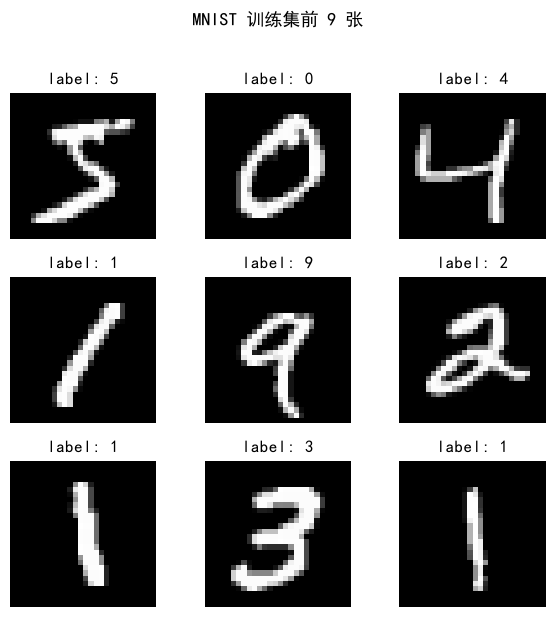

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
	img, label = train_set[i]
	# img 是经过归一化后的结果，需要反归一化才能正常显示
	ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap='gray')
	ax.set_title(f"label: {label}", fontsize = 12)
	ax.axis('off')
plt.suptitle('MNIST 训练集前 9 张', fontsize = 13, y = 1.02)
plt.tight_layout()
plt.show()

# 实现训练

### 参数的初始化

手动初始化 4 个参数张量: W1, b1, W2, b2  
单独运行这段代码，再次固定随机种子，确保权重初始化可复现  

In [10]:
torch.manual_seed(42)

- `requires_grad=True`:  
 	向 autograd 声明该张量是参数，需要记录梯度  
 	没有这个标记，`loss.backward()` 计算不出 `p.grad`  

- `(2.0 / n_in) ** 0.5`:  
 	是 He 初始化的标准差，专门适用 ReLU 网络  
 	是经验值，在参数初始化章节展开介绍 `sqrt(2/n_in)`  

In [11]:
W1 = (torch.randn(784, 128) * (2.0 / 784) ** 0.5).requires_grad_()
b1 = torch.zeros(128, requires_grad=True)

- 第 2 层:  
	128 → 10 (输出 10 个类别的 logits)  

In [12]:
W2 = (torch.randn(128, 10) * (2.0 / 128) ** 0.5).requires_grad_()
b2 = torch.zeros(10, requires_grad=True)

将 4 个参数放入同个列表，后续统一更新  
`lr` 控制梯度下降幅度，在学习率章节展开介绍

In [13]:
params = [W1, b1, W2, b2]
lr = 0.1

print(f"网络共 {sum(p.numel() for p in params):,} 个参数")

网络共 101,770 个参数


### 迭代训练

训练 5 个 epoch  
- 每个 epoch 遍历整个训练集 (6e+4 张图片)  
- 每个 batch 包含由 `DataLoader` 划分的 128 张图片，因此每个 epoch 大约有 469 个 batch  

`running_loss` 累积本轮 epoch 所有 batch 的 loss × 样本数，用于最后求平均值  
`xb` 输入 shape (批量, 通道, 高, 宽) (128, 1, 28, 28)  
`yb` 输出 shape (批量,) (128, )  
`xb.view()` 将图片展平为 1D 向量，形状 (128, 784)  

1. 前向传播 forward  
	- `h` 隐藏层:  
		内层线性变换，再使用 ReLU 激活非线性  
	- `logits` 输出层:  
		只做线性变换，不加 softmax
		后续 CrossEntropy 内部包含 log_softmax
2. 计算损失 loss  
	- `cross_entropy`:  
		接收 logits (未归一化的分数) 和整数标签  
		自动完成 softmax + 交叉熵的计算  
3. 反向传播 backward  
	- `autograd`:  
		根据前向计算图，从 loss 对每个 required_grad 的张量链式求导
4. 梯度下降 step  
	- `with torch.no_grad`:  
		参数更新本身无需建图，即无需对"更新参数"的操作求导  
	- `p.grad_zero_()`:  
		PyTorch 默认累加梯度  
		手动清零梯度，避免在下个 batch 中的梯度累加  

评估本轮 epoch 训练后在测试集上的准确率

In [ ]:
train_losses = []	# 训练损失
test_accs =[]	# 测试准确率

for epoch in range(5):
	# 累计本轮 epoch 所有 batch 的 loss × 样本数，用于最后求平均值
	running_loss = 0.0
	n_samples = 0

	for xb, yb in train_loader:
		# xb 形状 (128, 1, 28, 28)
		# xy 形状 (128, )
		# 将图片展平为 1D 向量，形状 (128, 784)
		x = xb.view(-1, 784)

		# 1. 前向传播 forward :
		# 隐藏层: 内层线性变换，再使用 ReLU 激活非线性
		h = F.relu(x @ W1 + b1)
		# 输出层: 只做线性变换，不加 softmax
		# 后续 CrossEntropy 内部包含 log_softmax
		logits = h @ W2 + b2

		# 2. 计算损失 loss
		# cross_entropy: 接收 logits (未归一化的分数) 和整数标签
		# 自动完成 softmax + 交叉熵的计算
		loss = F.cross_entropy(logits, yb)

		# 3. 反向传播 backward
		# autograd 根据前向计算图，从 loss 对每个 required_grad 的张量链式求导
		loss.backward()

		# 4. 梯度下降 step : 沿梯度反方向更新参数
		# 参数更新本身无需建图，即无需对"更新参数"的操作求导
		with torch.no_grad():
			for p in params:
				p -= lr * p.grad
				# PyTorch 默认累加梯度
				# 手动清零梯度，避免在下个 batch 中的梯度累加
				p.grad.zero_()

		running_loss += loss.item() * yb.size(0)
		n_samples += yb.size(0)

	# 计算 epoch 的平均训练损失
	train_loss = running_loss / n_samples

	# 评估: 在测试集上完成一遍前向传播，计算准确率
	correct = 0
	with torch.no_grad():
		for xb, yb in test_loader:
			x = xb.view(-1, 784)
			logits = F.relu(x @ W1 + b1) @ W2 + b2
			correct += (logits.argmax(1) ==yb).sum().item()
	test_acc = correct / len(test_set)

	train_losses.append(train_loss)
	test_accs.append(test_acc)
	print(f"epoch {epoch + 1}/5 train_loss = {train_loss:.4f} test_acc = {test_acc:.4f}")

epoch 1/5 train_loss = 0.2839 test_acc = 0.9486
epoch 2/5 train_loss = 0.1387 test_acc = 0.9649
epoch 3/5 train_loss = 0.1011 test_acc = 0.9672
epoch 4/5 train_loss = 0.0805 test_acc = 0.9712
epoch 5/5 train_loss = 0.0670 test_acc = 0.9733


### 绘制训练曲线

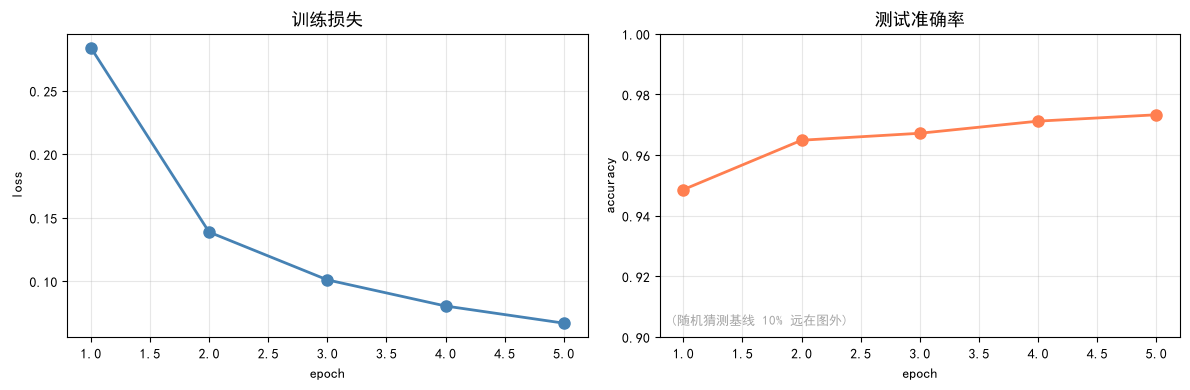

In [ ]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize = (12, 4))
epochs = range(1, len(train_losses) + 1)

# 训练损失 —— 理想形态单调下降
axes[0].plot(epochs, train_losses, '-o', color = 'steelblue', lw = 2, markersize = 8)
axes[0].set_title('训练损失', fontsize = 13)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].grid(alpha = 0.3)

# 测试准确率 —— 理想形态单调上升
axes[1].plot(epochs, test_accs, '-o', color = 'coral', lw = 2, markersize = 8)
axes[1].set_title('测试准确率', fontsize = 13)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0.9, 1.0)
axes[1].annotate('(随机猜测基线 10% 远在图外)', xy = (0.02, 0.04), xycoords = 'axes fraction', fontsize = 9, color = 'gray', alpha = 0.7)

axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()


# 标准 PyTorch 实现
实际工程利用 PyTorch 内置工具更加简便:  
- `nn.Module` :  
	打包 "网络构造 + 参数管理"  
- `torch.optim` :  
	打包 "step + zero_grad"  
- `nn.Linear` :  
	打包 "W @ x + b"  

如下代码与前文的代码等价，每行都和前文步骤对应

## 定义网络类

- `nn.Linear(in, out)`  
	一行同时构造 W (out × in) 和 b (out)  
	默认初始化是 Kaiming uniform 和前文的 He normal 不全相同，但都使用 ReLU  
- `x.view()`  
	将输入值展平  

In [3]:
class SimpleMLP(nn.Module):
	"""
	两层 MLP : 784 → 128 → 10
	继承 nn.Module 之后，通过 PyTorch 自动管理: 
	- 集中 self.fcN 中的参数 (model.parameters())  
	- .train() / .eval() 自动切换 Dropout, BN 等层行为  
	- .to(device) 将所有参数转移至 GPU  
	"""
	def __init__(self):
		super().__init__()
		# nn.Linear(in, out) 一行同时构造 W (out × in) 和 b (out)  
		# 默认初始化是 Kaiming uniform 和前文的 He normal 不全相同， 但都使用 ReLU  
		self.fc1 = nn.Linear(784, 128)	# 等价于 W1, b1
		self.fc2 = nn.Linear(128, 10)	# 等价于 W2, b2

	def forward(self, x):
		x = x.view(-1, 784)	# 展平 (batch, 784)
		x = F.relu(self.fc1(x))	# 隐藏层 + ReLU
		return self.fc2(x)	# 输出 logits


## 选定配置
1. 随机种子  
	 `torch.manual_seed()`  
2. 优化器  
	 SGD 包含 `p -= lr * p.grad`  
3. 损失函数  
	 `nn.CrossEntropyLoss()` 等价 `F.cross_entropy`  

In [9]:
torch.manual_seed(42)
model = SimpleMLP()
# SGD 包含 `p -= lr * p.grad`
optimizer = optim.SGD(model.parameters(), lr = 0.1)
loss_fn = nn.CrossEntropyLoss()	# 等价于 F.cross_entropy


## 迭代训练

- `train_losses_v2`  
	 记录训练损失  
- `test_accs_v2`  
	 记录测试准确率  
- `model.train()`  
	切换训练模式  
- `optimizer.zero_grad()`  
	等价 `p.grad.zero_()`, 一行清零所有参数梯度
- `model(xb)`  
	 等价 model.forward(xb)  
- `optimizer.step()`  
	等价 `p -= lr + p.grad`  
- `model.eval()`  
	 切换评估模式  

In [10]:
train_losses_v2 = []
test_accs_v2 = []

for epoch in range(5):
	model.train() # 进入训练模式, Dropout/BN 行为切换
	running_loss = 0.0
	n_samples = 0
	for xb, yb in train_loader:
		# 等价于 `p.grad.zero_()`, 一行清零所有参数梯度
		optimizer.zero_grad()
		# 1. forward 等价 model.forward(xb)
		logits = model(xb)
		# 2. loss
		loss = loss_fn(logits, yb)
		# 3. backward, 通过 autograd 完成
		loss.backward()
		# 4. step, 等价 `p -= lr + p.grad`
		optimizer.step()
		running_loss += loss.item() * yb.size(0)
		n_samples += yb.size(0)

	model.eval() # 进入评估模式
	correct = 0
	with torch.no_grad():
		for xb, yb in test_loader:
			correct += (model(xb).argmax(1) == yb).sum().item()

		train_losses_v2.append(running_loss / n_samples)
		test_accs_v2.append(correct / len(test_set))
		print(f"epoch {epoch + 1}/5 train_loss = {train_losses_v2[-1]:.4f} test_acc = {test_accs_v2[-1]:.4f}")

epoch 1/5 train_loss = 0.3329 test_acc = 0.9466
epoch 2/5 train_loss = 0.1606 test_acc = 0.9627
epoch 3/5 train_loss = 0.1147 test_acc = 0.9680
epoch 4/5 train_loss = 0.0915 test_acc = 0.9727
epoch 5/5 train_loss = 0.0738 test_acc = 0.9752


# 使用模型识别图片

## 在测试集中尝试预测
随机抽取 9 张测试图，通过模型完成预测  
绿色表示正确，红色表示错误  
- `random.seed(7)`  
	设定随机种子  
- `with torch.no_grad()`  
	关闭梯度，节省内存，提升速度  
- `img.unsqueeze(0)`  
	img 形状 (1, 28, 28)  
	模型期望 (batch, 1, 28, 28)  
	因此 unsqueeze(0) 补充一项维度  

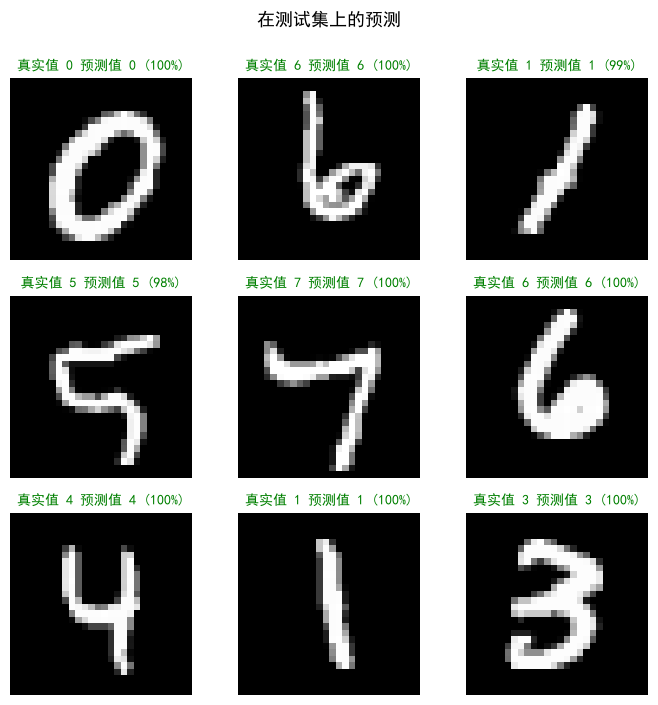

In [ ]:
import random
random.seed(42)
indices = random.sample(range(len(test_set)), 9)

model.eval() # 推理模式
fig, axes = plt.subplots(3, 3, figsize = (7, 7))
with torch.no_grad(): # 推理过程关闭梯度，节省内存提升速度
	for ax, idx in zip(axes.flat, indices):
		img, label = test_set[idx]
		# img 形状 (1, 28, 28)  
		# 模型期望 (batch, 1, 28, 28)  
		# 因此 unsqueeze(0) 补充一项维度  
		logits = model(img.unsqueeze(0))
		# softmax 将 logits 变为概率分布: [0] 是 batch = 1 维度
		probs = F.softmax(logits, dim = 1)[0]
		pred = int(probs.argmax())	# 选取概率最大的类标签
		conf = float(probs[pred])	# 预测的置信度

		ax.imshow(img.squeeze() * 0.3081 + 0.1307, cmap = 'gray')
		ok = (pred == label)
		ax.set_title(f"真实值 {label} 预测值 {pred} ({conf:.0%})", fontsize = 10, color = ("green" if ok else "red"))
		ax.axis("off")

plt.suptitle("在测试集上的预测", fontsize = 13, y = 1.00)
plt.tight_layout()
plt.show()

## 在交互画板上尝试预测

这部分的代码来自 [WangSen679:handwritten-digit-classification](https://github.com/WangSen679/DL_qx2io/tree/handwritten-digit-classification) 对原作的整理, 再次感谢你的支持  
详见 [Pull Request #2](https://github.com/NothingForID/Deep_Learning/pull/2). 

由于该部分与深度学习的直接关联有限，我个人没有过多投入  
仅简单补充注释:  
- `CANVAS_SIZE`  
	设置画板尺寸，原作建议 28 的整数倍确保缩放效果  
- `LINE_WIDTH`  
	根据画板尺寸自动缩放笔触粗细  
- `canvas.layout`  
	原作提醒: 在 JupyterLab 中 CSS 默认将 Canvas 设为全宽，必须显式约束 layout 的大小

In [ ]:
from IPython.display import display
from ipycanvas import Canvas
from ipywidgets import Button, HBox, VBox, Output
from PIL import Image

# 画板设置
CANVAS_SIZE= 560
LINE_WIDTH = max(8, CANVAS_SIZE // 14)  # 根据画板宽度动态设置线条宽度

canvas = Canvas(width=CANVAS_SIZE, height=CANVAS_SIZE, sync_image_data=True)
canvas.layout.width = f'{CANVAS_SIZE}px'
canvas.layout.height = f'{CANVAS_SIZE}px'
canvas.fill_style = 'black'
canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)  # 黑色背景
canvas.stroke_style = 'white'
canvas.line_width = LINE_WIDTH

brush = {'down': False, 'last': None}

def on_mouse_down(x, y):
    brush['down'] = True
    brush['last'] = (x, y)

def on_mouse_move(x, y):
    if brush['down'] and brush['last'] is not None:
        canvas.stroke_line(brush['last'][0], brush['last'][1], x, y)
        brush['last'] = (x, y)

def on_mouse_up(x, y):
    brush['down'] = False
    brush['last'] = None

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

output = Output()
btn_predict = Button(description='识别', button_style='primary', icon='check')
btn_clear = Button(description='清空', icon='trash')

def predict(_):
    output.clear_output()

    arr = canvas.get_image_data()
    if arr is None:
        with output:
            print('画板还没准备好，等 1 秒再试，或者现在画板上随便画一笔')
        return
    img = Image.fromarray(arr).convert('L')
    img = img.resize((28, 28), Image.LANCZOS)
    arr28 = np.array(img, dtype=np.float32)/255.0

    x = (torch.from_numpy(arr28) - 0.1307) / 0.3081

    model.eval()
    with torch.no_grad():
        logits = model(x.unsqueeze(0))  # 增加 batch 维度
        probs = F.softmax(logits, dim=1)[0].numpy()
    pred = int(probs.argmax())

    with output:
        fig, ax = plt.subplots(1, 2, figsize=(9, 3))
        ax[0].imshow(arr28, cmap='gray')
        ax[0].set_title('模型看到的（28 × 28）', fontsize=12)
        ax[0].axis('off')
        ax[1].bar(range(10), probs,
                  color=['coral' if i == pred else 'lightsteelblue' for i in range(10)])
        ax[1].set_xticks(range(10))
        ax[1].set_xlabel('类别')
        ax[1].set_ylim(0, 1)
        ax[1].set_title(f'模型预测 {pred}，置信度 {probs[pred]:.1%}', fontsize=12)
        ax[1].grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

def clear_canvas(_):
    canvas.clear()
    canvas.fill_style = 'black'
    canvas.fill_rect(0, 0, CANVAS_SIZE, CANVAS_SIZE)
    output.clear_output()

btn_predict.on_click(predict)
btn_clear.on_click(clear_canvas)

container = VBox(
    [canvas, HBox([btn_predict, btn_clear]), output],
    layout={'width': f'{CANVAS_SIZE+20}px', 'align_items': 'flex-start'},
    )
display(container)